
Top 12 MI-selected features:
['Follicle No. (L)', 'Follicle No. (R)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Cycle length(days)', 'Skin darkening (Y/N)', 'AMH(ng/mL)', 'Hip(inch)', 'Fast food (Y/N)', 'Cycle(R/I)', 'PRL(ng/mL)', 'Pulse rate(bpm) ']

Training class distribution after SMOTE:
PCOS (Y/N)
0    291
1    291
Name: count, dtype: int64

===== Random Forest =====
Accuracy  : 89.91%
Precision : 85.71%
Recall    : 83.33%
F1 Score  : 84.51%

===== Gaussian NB =====
Accuracy  : 92.66%
Precision : 85.00%
Recall    : 94.44%
F1 Score  : 89.47%

===== SVM =====
Accuracy  : 90.83%
Precision : 86.11%
Recall    : 86.11%
F1 Score  : 86.11%

===== Logistic Regression =====
Accuracy  : 90.83%
Precision : 86.11%
Recall    : 86.11%
F1 Score  : 86.11%


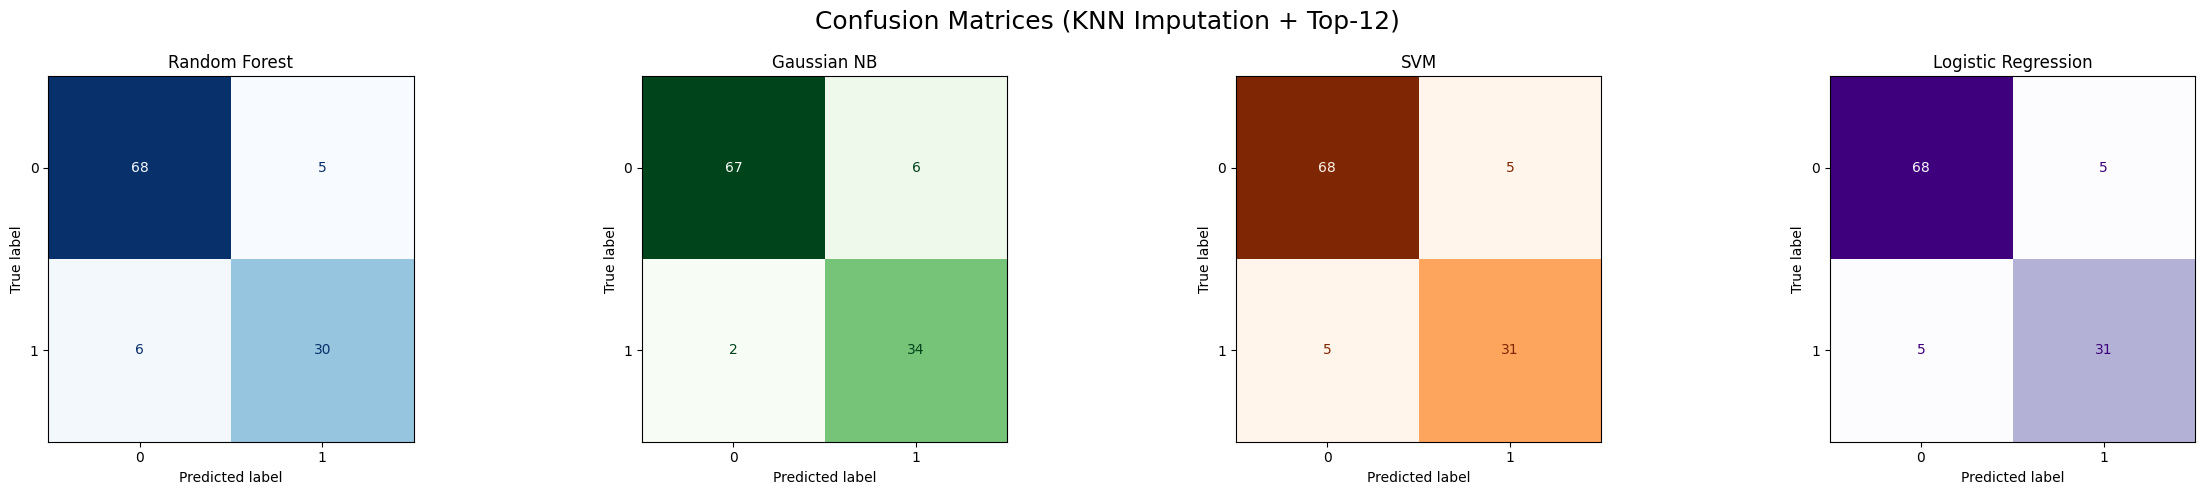

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.impute import KNNImputer

from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from imblearn.over_sampling import SMOTE

# 1. LOAD DATA
df = pd.read_excel("PCOS_data.xlsx", sheet_name='Full_new')
df = df.drop(columns=['Sl. No', 'Patient File No.'])

# Convert object columns to numeric
df['II    beta-HCG(mIU/mL)'] = pd.to_numeric(df['II    beta-HCG(mIU/mL)'], errors='coerce')
df['AMH(ng/mL)'] = pd.to_numeric(df['AMH(ng/mL)'], errors='coerce')

# Separate features and target
X = df.drop(columns=['PCOS (Y/N)'])
y = df['PCOS (Y/N)']

#  2. TRAIN / TEST SPLIT (FIRST)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. KNN IMPUTATION (TRAIN ONLY) 
imputer = KNNImputer(n_neighbors=5, weights="distance")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

X_train_imp = pd.DataFrame(X_train_imp, columns=X.columns)
X_test_imp = pd.DataFrame(X_test_imp, columns=X.columns)

# 4. FEATURE SELECTION (MI on TRAIN) 
mi_scores = mutual_info_classif(X_train_imp, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns)

top_features = mi_series.sort_values(ascending=False).head(12).index
X_train_top12 = X_train_imp[top_features]
X_test_top12 = X_test_imp[top_features]

print("\nTop 12 MI-selected features:")
print(list(top_features))

# 5. APPLY SMOTE (ONLY ON TRAIN) 
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_top12, y_train)

print("\nTraining class distribution after SMOTE:")
print(y_train_bal.value_counts())

#  6. SCALE (ONLY FOR LINEAR MODELS) 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test_top12)

#  7. MODELS 
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42
    ),

    "Gaussian NB": GaussianNB(),

    "SVM": SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    )
}

preds = {}

#  8. TRAIN & EVALUATE
for name, model in models.items():

    if name in ["SVM", "Logistic Regression"]:
        model.fit(X_train_scaled, y_train_bal)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train_bal, y_train_bal)
        y_pred = model.predict(X_test_top12)

    preds[name] = y_pred

    print(f"\n===== {name} =====")
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.2%}")
    print(f"Precision : {precision_score(y_test, y_pred):.2%}")
    print(f"Recall    : {recall_score(y_test, y_pred):.2%}")
    print(f"F1 Score  : {f1_score(y_test, y_pred):.2%}")

# 9. CONFUSION MATRICES
fig, axs = plt.subplots(1, len(models), figsize=(24, 5))
fig.suptitle("Confusion Matrices (KNN Imputation + Top-12)", fontsize=18)

cmaps = ["Blues", "Greens", "Oranges", "Purples"]

for i, (name, y_pred) in enumerate(preds.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(
        ax=axs[i],
        cmap=cmaps[i],
        values_format='d',
        colorbar=False
    )
    axs[i].set_title(name)

plt.tight_layout()
plt.show()



===== HYBRID MODEL (NB + LR + RF) =====
Accuracy  : 92.66%
Precision : 86.84%
Recall    : 91.67%
F1 Score  : 89.19%


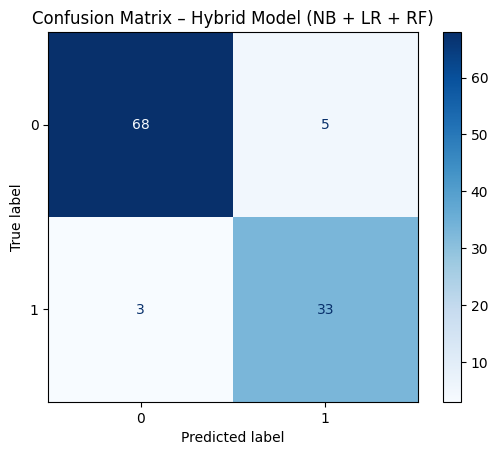

In [2]:
from sklearn.ensemble import VotingClassifier

# HYBRID MODEL

nb = GaussianNB()

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

# Weighted Soft Voting Hybrid
hybrid_model = VotingClassifier(
    estimators=[
        ('nb', nb),
        ('lr', lr),
        ('rf', rf)
    ],
    voting='soft',
    weights=[3, 3, 2]   # NB & RF slightly higher weight
)

#  TRAIN HYBRID MODEL
hybrid_model.fit(X_train_scaled, y_train_bal)

#  PREDICT
y_pred_hybrid = hybrid_model.predict(X_test_scaled)

y_prob_hybrid = hybrid_model.predict_proba(X_test_scaled)[:, 1]

#  EVALUATION 
print("\n===== HYBRID MODEL (NB + LR + RF) =====")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_hybrid):.2%}")
print(f"Precision : {precision_score(y_test, y_pred_hybrid):.2%}")
print(f"Recall    : {recall_score(y_test, y_pred_hybrid):.2%}")
print(f"F1 Score  : {f1_score(y_test, y_pred_hybrid):.2%}")

#  CONFUSION MATRIX
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_hybrid)).plot(
    cmap="Blues",
    values_format="d"
)
plt.title("Confusion Matrix – Hybrid Model (NB + LR + RF)")
plt.show()



In [1]:
# ===================== 1. IMPORTS =====================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# ===================== 2. DATA PREPARATION =====================

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    'Dataset/Train',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    'Dataset/Train',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

test_data = test_datagen.flow_from_directory(
    'Dataset/Test',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 1271 images belonging to 2 classes.
Found 317 images belonging to 2 classes.
Found 398 images belonging to 2 classes.


In [3]:
# ===================== 3. CUSTOM BLOCKS =====================

# SE Attention
def se_block(input_tensor, ratio=8):
    filters = input_tensor.shape[-1]
    se = layers.GlobalAveragePooling2D()(input_tensor)
    se = layers.Dense(filters // ratio, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1,1,filters))(se)
    return layers.multiply([input_tensor, se])

# Spatial Attention
from tensorflow.keras import backend as K

def spatial_attention(input_tensor):
    avg_pool = layers.Lambda(lambda x: K.mean(x, axis=-1, keepdims=True))(input_tensor)
    max_pool = layers.Lambda(lambda x: K.max(x, axis=-1, keepdims=True))(input_tensor)
    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    attention = layers.Conv2D(1, (7,7), padding='same', activation='sigmoid')(concat)
    return layers.multiply([input_tensor, attention])

# Residual Block
def residual_block(x, filters):
    shortcut = x

    x = layers.Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), padding='same')(shortcut)

    x = layers.add([x, shortcut])
    return layers.Activation('relu')(x)

In [4]:
# ===================== 4. BASE MODEL =====================

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

# Fine-tune last layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

# =====================  HYBRID ARCHITECTURE =====================

x = base_model.output

# Residual + Attention
x = residual_block(x, 128)
x = se_block(x)
x = spatial_attention(x)

# Additional CNN layer
x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.BatchNormalization()(x)

# Global pooling
x = layers.GlobalAveragePooling2D()(x)

# Dense layers
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(64, activation='relu')(x)

# Output
output = layers.Dense(1, activation='sigmoid')(x)

# Final model
model = models.Model(inputs=base_model.input, outputs=output)

In [5]:
# ===================== 5. COMPILE =====================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 4,140,788 (15.80 MB)

 Trainable params: 3,408,308 (13.00 MB)

 Non-trainable params: 732,480 (2.79 MB)

In [8]:
# ===================== 6. TRAIN =====================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight={0:1, 1:2} 
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step - accuracy: 0.9992 - loss: 0.0061 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 1.0000 - loss: 0.0064 - val_accuracy: 1.0000 - val_loss: 0.0044
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 0.0039
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.9984 - loss: 0.0074 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9984 - loss: 0.0081 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 133s 3s/step - accuracy: 0.9992 - loss: 0.0064 - val_accuracy: 1.0000 - val_loss: 0.0038
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 1.0000 - val_

In [9]:
# ===================== 7. EVALUATE =====================
loss, acc = model.evaluate(test_data)
print(f"\nTest Accuracy: {acc:.2%}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9975 - loss: 0.0025   

Test Accuracy: 99.75%


In [11]:
model.save("ultrasound_model.h5")

In [10]:
# ===================== 8. PREDICTIONS =====================
preds = model.predict(test_data)
preds = (preds > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Step 1: Get probabilities
y_prob = model.predict(test_data)

# Step 2: Convert to binary predictions
y_pred = (y_prob > 0.5).astype(int).ravel()

# Step 3: True labels
y_true = test_data.classes

# Step 4: Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Step 5: Print results
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step
Accuracy : 0.9974874371859297
Precision: 1.0
Recall   : 0.9940828402366864
F1 Score : 0.9970326409495549


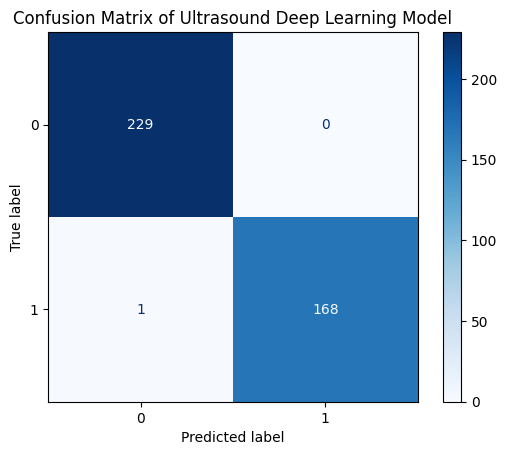

In [17]:
# ===================== 9. CONFUSION MATRIX =====================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_data.classes, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix of Ultrasound Deep Learning Model")
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step


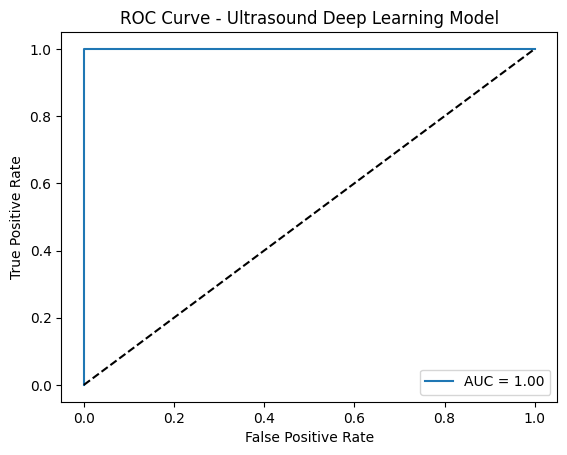

In [18]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_true = test_data.classes
y_prob = model.predict(test_data).flatten()

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], 'k--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Ultrasound Deep Learning Model")
plt.legend()
plt.show()

In [30]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

resnet_model = models.Model(inputs=base_model.input, outputs=output)

resnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

resnet_model.fit(train_data, validation_data=val_data, epochs=10)

loss, acc = resnet_model.evaluate(test_data)
print(f"ResNet Accuracy: {acc:.2%}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 34s 0us/step
Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 321s 8s/step - accuracy: 0.6129 - loss: 0.6904 - val_accuracy: 0.8580 - val_loss: 0.5737
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 350s 9s/step - accuracy: 0.7797 - loss: 0.5341 - val_accuracy: 0.8612 - val_loss: 0.4851
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 347s 9s/step - accuracy: 0.8096 - loss: 0.4688 - val_accuracy: 0.8360 - val_loss: 0.4049
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 282s 7s/step - accuracy: 0.8285 - loss: 0.4120 - val_accuracy: 0.8328 - val_loss: 0.3574
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 292s 7s/step - accuracy: 0.8426 - loss: 0.3838 - val_accuracy: 0.8612 - val_loss: 0.3337
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 315s 8s/step - accuracy: 0.8710 - loss: 0.3377 - val_accuracy: 0.8770 - val_loss: 0.3147
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 291s 7s/step - accuracy: 0.8678 - loss: 0.3305 - val_accuracy: 0.9117 - val_loss: 0.2931
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 312s 7s/step - accura

In [32]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(1, activation='sigmoid')(x)

efficientnet_model = models.Model(inputs=base_model.input, outputs=output)

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # VERY SMALL LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [33]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = efficientnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.5028 - loss: 0.8964 - val_accuracy: 0.5741 - val_loss: 0.6826
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.5146 - loss: 0.8745 - val_accuracy: 0.5741 - val_loss: 0.6861
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.4996 - loss: 0.8718 - val_accuracy: 0.4259 - val_loss: 0.6960
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.4988 - loss: 0.8437 - val_accuracy: 0.4259 - val_loss: 0.7012


In [34]:
loss, acc = efficientnet_model.evaluate(test_data)
print(f"Improved EfficientNet Accuracy: {acc:.2%}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.5754 - loss: 0.6821
Improved EfficientNet Accuracy: 57.54%


In [6]:
# ===================== 1. IMPORTS =====================
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# ===================== 2. LOAD BASE MODEL =====================
base_model = VGG16(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

# Freeze all layers
base_model.trainable = False

# ===================== 3. BUILD MODEL =====================
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(1, activation='sigmoid')(x)

vgg_model = models.Model(inputs=base_model.input, outputs=output)

# ===================== 4. COMPILE =====================
vgg_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

vgg_model.summary()

# ===================== 5. TRAIN =====================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = vgg_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

# ===================== 6. EVALUATE =====================
loss, acc = vgg_model.evaluate(test_data)
print(f"VGG16 (Frozen) Accuracy: {acc:.2%}")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          65,6

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 907s 23s/step - accuracy: 0.7522 - loss: 0.5614 - val_accuracy: 0.9968 - val_loss: 0.3105
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 939s 23s/step - accuracy: 0.9819 - loss: 0.2148 - val_accuracy: 1.0000 - val_loss: 0.1147
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 988s 25s/step - accuracy: 0.9969 - loss: 0.0940 - val_accuracy: 1.0000 - val_loss: 0.0463
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1001s 25s/step - accuracy: 0.9961 - loss: 0.0517 - val_accuracy: 1.0000 - val_loss: 0.0278
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1089s 26s/step - accuracy: 0.9984 - loss: 0.0300 - val_accuracy: 1.0000 - val_loss: 0.0156
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1001s 25s/step - accuracy: 0.9984 - loss: 0.0225 - val_accuracy: 1.0000 - val_loss: 0.0102
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1077s 26s/step - accuracy: 0.9992 - loss: 0.0167 - val_accuracy: 1.0000 - val_loss: 0.0072
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1006s 25s/step - accuracy: 1.0000 - loss: 0.0125 - val_accurac